# California Wildfire PM2.5 Pollution Risk Classifier on Prison and Detention Facilities

## Part 5: Creating Risk Tier Map 

In [1]:
import os 
import json
import folium 
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path
from datetime import datetime

In [2]:
# Obtaining Path files to the data in data folder

directory_name = os.getcwd()
directory_path = Path(directory_name)

# Facilities geometries path
fac_geometries = pd.read_pickle(directory_path.joinpath('data/final_facilities_data.pkl'))

# Final deliverable path
final_deliverable = pd.read_pickle(directory_path.joinpath('data/final_deliverable.pkl'))

In [96]:
# Set geometries to single facilities 
copy_geometries = fac_geometries.copy()
copy_single_geometry = copy_geometries.drop_duplicates(subset=['Institution Name', 'ID'])
copy_single_geometry.drop(copy_single_geometry.columns[[1, 2, 3, 4, 5]], axis=1, inplace=True)

# Merge dataframes together 
merged_df = final_deliverable.merge(copy_single_geometry, on=['ID'], how='left')

# Add consolidated Date column
merged_df['Date'] = pd.to_datetime(merged_df[['Year', 'Month']].assign(day=1)).dt.to_period('M')

# Create into GeoDataFrame
final_deliverable_gdf = gpd.GeoDataFrame(merged_df, geometry='Geometry', crs='EPSG:4326')
single_fac_gdf = final_deliverable_gdf.drop_duplicates(subset=['ID'])

/var/folders/qf/cq7m_hx954l_s2pj_f4cs6nh0000gn/T/ipykernel_41799/680216058.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  copy_single_geometry.drop(copy_single_geometry.columns[[1, 2, 3, 4, 5]], axis=1, inplace=True)


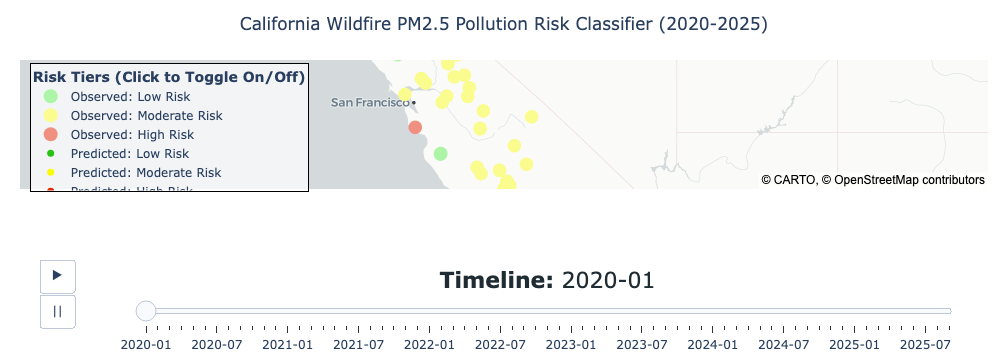

In [97]:
# Mapping via Plotly
# Setting and sorting by dates correctly 
final_deliverable_gdf['Date'] = final_deliverable_gdf['Date'].dt.to_timestamp()
final_deliverable_gdf['Month_Str'] = final_deliverable_gdf['Date'].dt.strftime('%Y-%m')

# Filling N/A values with Null, and setting column information to be used when hovering over markers
hover_columns = ['Facility Type', 'max_pm_conc', 'Actual Risk Tier', 'Predicted Risk Tier', 
              'Model Accuracy', 'Model Precision', 'Model Recall']

final_deliverable_clean = final_deliverable_gdf.copy()
for column in hover_columns:
    final_deliverable_clean[column] = final_deliverable_clean[column].fillna('Null')

# Split into observed and predicted risk tiers
actuals_df = final_deliverable_clean[final_deliverable_clean['Actual Risk Tier'] != 'Unknown'].copy()
actuals_df['Category'] = 'Observed: ' + actuals_df['Actual Risk Tier'].astype(str)

predicted_df = final_deliverable_clean[final_deliverable_clean['Data Status'].isin(['Model Prediction', 'Validation Period (2024-2025)'])].copy()
predicted_df['Category'] = 'Predicted: ' + predicted_df['Predicted Risk Tier'].astype(str)

# Combine as map df
map_df = pd.concat([obs_df, pred_df])

# Defining categories
categories = {
    'Observed: Low Risk':      {'color':'#ADF5A6', 'size': 14, 'opacity': 1.0},
    'Observed: Moderate Risk': {'color':'#FAFC8D', 'size': 14, 'opacity': 1.0},
    'Observed: High Risk':     {'color':'#F09081', 'size': 14, 'opacity': 1.0},
    'Predicted: Low Risk':     {'color':'#2AC215', 'size': 7,  'opacity': 1.0},
    'Predicted: Moderate Risk':{'color':'#FAFA0A', 'size': 7,  'opacity': 1.0},
    'Predicted: High Risk':    {'color':'#E32B07', 'size': 7,  'opacity': 1.0}
}

hover_template = (
    "<b>%{text}</b><br>" +
    "Facility Type: %{customdata[0]}<br>" +
    "PM2.5 Concentration: %{customdata[1]:.2f}<br>" +
    "Actual Risk: %{customdata[2]}<br>" +
    "Predicted Risk: %{customdata[3]}<br>" +
    "Model Accuracy: %{customdata[4]}<br>" +
    "Model Risk Precision: %{customdata[5]}<br>" +
    "Model Risk Recall: %{customdata[6]}<extra></extra>"
)

# Initializing figure
fig = go.Figure()
unique_months = sorted(map_df['Month_Str'].unique())
first_month = unique_months[0]

# Initializing trace so all parameters show 
for category_name, style in categories.items():
    filtered_df = map_df[(map_df['Month_Str'] == first_month) & (map_df['Category'] == category_name)]
    
    fig.add_trace(go.Scattermap(
        name=category_name,
        lat=filtered_df['Latitude'] if not filtered_df.empty else [None],
        lon=filtered_df['Longitude'] if not filtered_df.empty else [None],
        mode='markers',
        marker=dict(color=style['color'], size=style['size'], opacity=style['opacity']),
        text=filtered_df['Institution Name'] if not filtered_df.empty else [None],
        customdata=filtered_df[hover_cols] if not filtered_df.empty else [[None]*7],
        hovertemplate=hover_template,
        showlegend=True
    ))

# Iterate map_df to get frames for each month-year
all_frames = []
for date in unique_months:
    frame_data = []
    for category_name, style in categories.items():
        filtered_df = map_df[(map_df['Month_Str'] == date) & (map_df['Category'] == category_name)]
        
        frame_data.append(go.Scattermap(
            lat=filtered_df['Latitude'] if not filtered_df.empty else [None],
            lon=filtered_df['Longitude'] if not filtered_df.empty else [None],
            text=filtered_df['Institution Name'] if not filtered_df.empty else [None],
            customdata=filtered_df[hover_cols] if not filtered_df.empty else [[None]*7],
            marker=dict(color=style['color'], size=style['size'], opacity=style['opacity'])
        ))
    all_frames.append(go.Frame(data=frame_data, name=str(date)))

fig.frames = all_frames

# Setting layout
slider_steps = []
for date in unique_months:
    slider_steps.append({
        "method": "animate",
        "label": str(date),
        "args": [[str(date)], {"frame": {"duration": 300, "redraw": True}, "mode": "immediate"}]
    })

fig.update_layout(
    title=dict(text="California Wildfire PM2.5 Pollution Risk Classifier (2020-2025)", x=0.5),
    map=dict(style="carto-positron", zoom=4.5, center=dict(lat=37.2, lon=-119.41)),
    updatemenus=[dict(
        type="buttons",
        showactive=False,
        x=0.02,         
        y=0,    
        xanchor="left",
        yanchor="top",
        pad={"t": 70},    
        buttons=[
            dict(
                label="▶", 
                method="animate", 
                args=[None, {"frame": {"duration": 500, "redraw": True}, "fromcurrent": True}]
            ),
            dict(
                label="||", 
                method="animate", 
                args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]
            )
        ]
    )],
    
    sliders=[dict(
        active=0,
        x=0.12,           
        len=0.85,        
        y=0,              
        pad={"t": 70},     
        currentvalue={
            "prefix": "<b>Timeline: </b>", 
            "font": {"size": 22, "color": "#1f2c33"}, 
            "visible": True,
            "xanchor": "center", 
            "offset": 15    
        },
        steps=slider_steps
    )],

    margin=dict(l=20, r=20, t=60, b=150), 
    
    legend=dict(
        title="<b>Risk Tiers (Click to Toggle On/Off)</b>",
        x=0.01, y=0.98, 
        bgcolor="rgba(255,255,255,0.7)", 
        bordercolor="black", 
        borderwidth=1
    )
)

fig.write_html('cwpp_risk_classifier_map.html')

fig.show()